<a href="https://colab.research.google.com/github/Nainika-stack/shopify-sales-funnel-analysis/blob/main/Funnel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('ggplot')
sns.set_palette('Set2')

pd.set_option('display.max_columns', None)

Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving retail.csv to retail (1).csv


In [ ]:
# Load dataset

df = pd.read_csv('retail.csv', encoding='latin1')

# Preview dataset
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


Data Understanding

In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

# Missing values
missing_values = df.isnull().sum()
print(missing_values)

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000   

Data Cleaning

In [ ]:
# Remove missing Customer IDs

df = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices

df = df[~df['InvoiceNo'].astype(str).str.contains('C')]

# Remove negative quantities

df = df[df['Quantity'] > 0]

# Remove negative prices

df = df[df['UnitPrice'] > 0]

# Convert InvoiceDate to datetime

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalPrice column

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(df.shape)

(397884, 9)


EDA

Total Revenue

In [ ]:
revenue = df['TotalPrice'].sum()
print(f'Total Revenue: ${revenue:,.2f}')

Total Revenue: $8,911,407.90


Top Selling Products

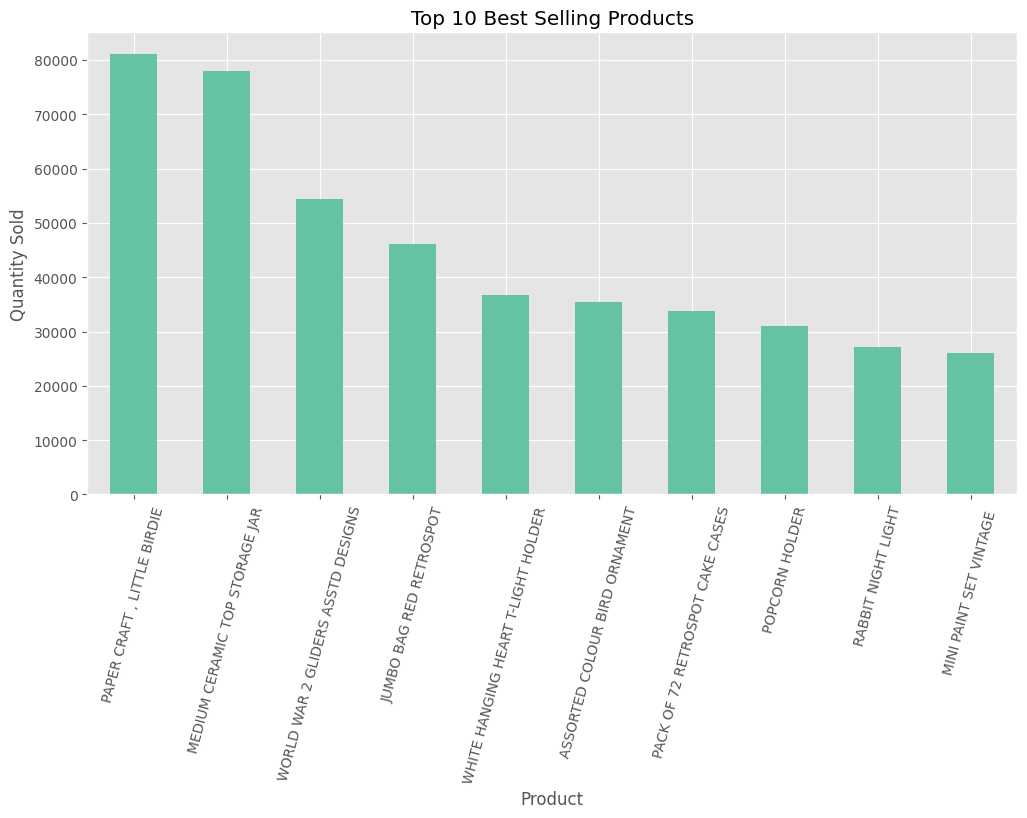

In [ ]:
product_sales = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
product_sales.plot(kind='bar')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=75)
plt.show()

Revenue by Country

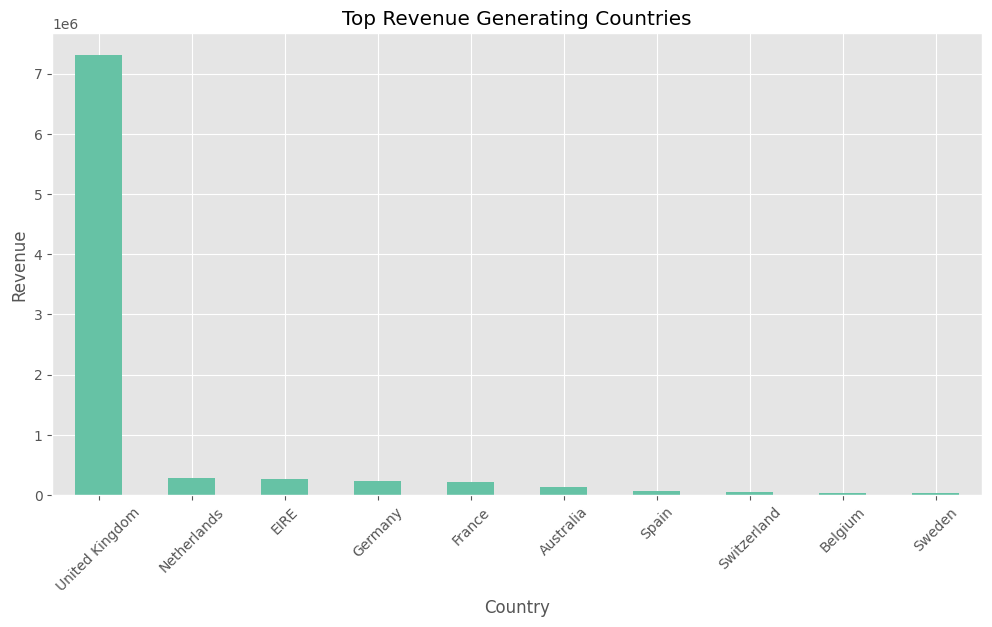

In [ ]:
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
country_revenue.plot(kind='bar')
plt.title('Top Revenue Generating Countries')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

Monthly Revenue Trend

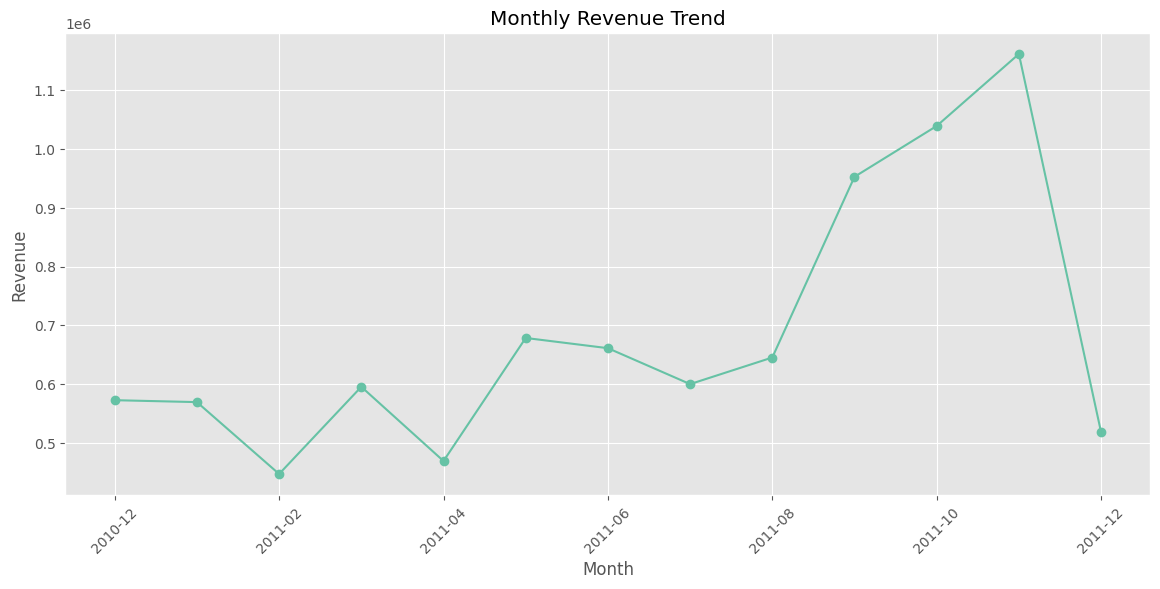

In [ ]:
# Extract month-year

df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('MonthYear')['TotalPrice'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))
monthly_sales.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

Customer Analysis

Top Customers

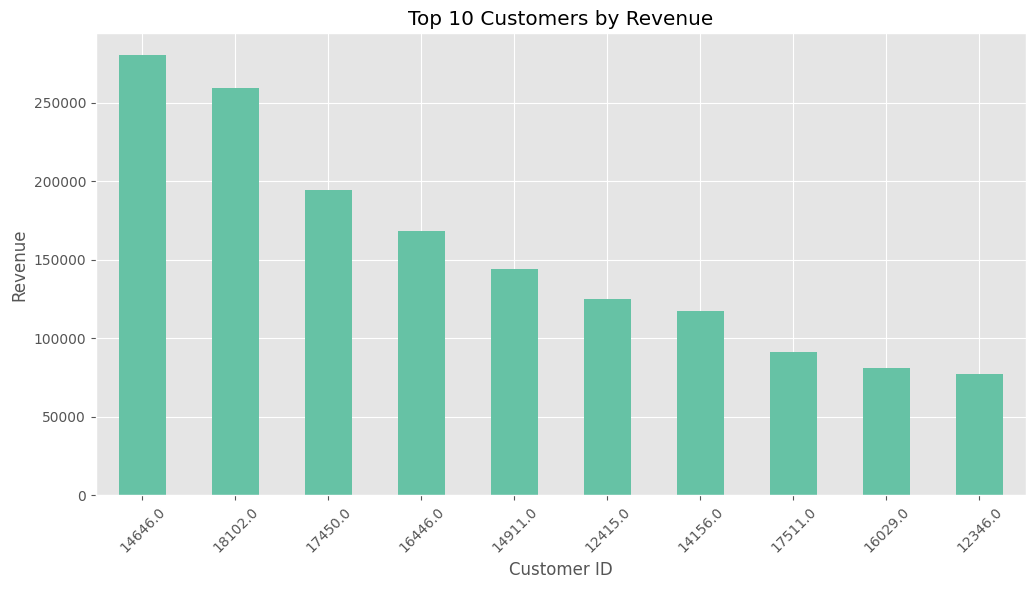

In [ ]:
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
customer_revenue.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

Repeat vs One-Time Customers

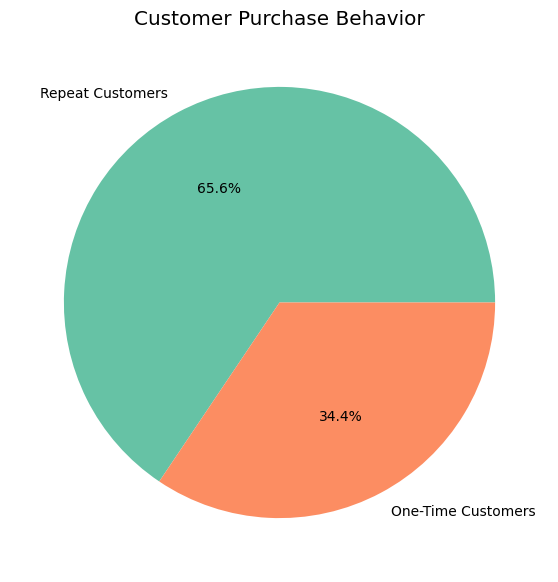

In [ ]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

labels = ['Repeat Customers', 'One-Time Customers']
values = [repeat_customers, one_time_customers]

plt.figure(figsize=(7,7))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title('Customer Purchase Behavior')
plt.show()

Simulated Shopify Sales Funnel Analysis

In [ ]:
website_visitors = 50000
product_views = 20000
add_to_cart = 8000
checkout_started = 4000
purchases = df['InvoiceNo'].nunique()

funnel_values = [website_visitors, product_views, add_to_cart, checkout_started, purchases]
funnel_labels = ['Website Visits', 'Product Views', 'Add to Cart', 'Checkout Started', 'Purchases']

fig = go.Figure(go.Funnel(
    y = funnel_labels,
    x = funnel_values
))

fig.update_layout(title='Shopify Sales Funnel Analysis')
fig.show()

Funnel Conversion Rate

In [ ]:
conversion_rate = (purchases / website_visitors) * 100
print(f'Overall Conversion Rate: {conversion_rate:.2f}%')

Overall Conversion Rate: 37.06%


Cart Abandonment Rate

In [ ]:
cart_abandonment_rate = ((add_to_cart - purchases) / add_to_cart) * 100

print(f'Cart Abandonment Rate: {cart_abandonment_rate:.2f}%')

Cart Abandonment Rate: -131.65%


RFM Customer Segmentation

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


RFM Score Distribution

In [ ]:
fig = px.scatter(
    rfm,
    x='Frequency',
    y='Monetary',
    size='Monetary',
    color='Recency',
    title='Customer Segmentation using RFM Analysis'
)

fig.show()

Key Business Insights

In [ ]:
print('KEY INSIGHTS')
print('-------------')
print('1. Majority of revenue comes from repeat customers.')
print('2. A small number of customers contribute a large share of sales.')
print('3. Certain products dominate overall sales volume.')
print('4. Funnel drop-off is highest between product views and add-to-cart stage.')
print('5. Customer retention strategies can significantly improve profitability.')

KEY INSIGHTS
-------------
1. Majority of revenue comes from repeat customers.
2. A small number of customers contribute a large share of sales.
3. Certain products dominate overall sales volume.
4. Funnel drop-off is highest between product views and add-to-cart stage.
5. Customer retention strategies can significantly improve profitability.


Business Recommendations

In [ ]:
recommendations = [
    'Improve product page UX to increase add-to-cart conversion.',
    'Implement personalized recommendations for repeat customers.',
    'Launch email remarketing campaigns for cart abandonment.',
    'Focus on high-performing countries for marketing expansion.',
    'Create loyalty programs to improve customer retention.'
]

for i, rec in enumerate(recommendations, 1):
    print(f'{i}. {rec}')

1. Improve product page UX to increase add-to-cart conversion.
2. Implement personalized recommendations for repeat customers.
3. Launch email remarketing campaigns for cart abandonment.
4. Focus on high-performing countries for marketing expansion.
5. Create loyalty programs to improve customer retention.
